In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
faceNet = cv2.dnn.readNet(
    "opencv_face_detector_uint8.pb",
    "opencv_face_detector.pbtxt"
)

ageNet = cv2.dnn.readNet(
    "age_net.caffemodel",
    "age_deploy.prototxt"
)

genderNet = cv2.dnn.readNet(
    "gender_net.caffemodel",
    "gender_deploy.prototxt"
)

print("Models loaded")

Models loaded


In [3]:
AGE_BUCKETS = [
    "(0-2)", "(4-6)", "(8-12)", "(15-20)",
    "(25-32)", "(38-43)", "(48-53)", "(60-100)"
]

GENDER_LIST = ["Male", "Female"]

MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)

In [4]:
def detect_faces(image):
    h, w = image.shape[:2]
    
    blob = cv2.dnn.blobFromImage(
        image, 1.0, (300, 300),
        [104, 117, 123], False
    )

    faceNet.setInput(blob)
    detections = faceNet.forward()

    boxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:  # lowered threshold
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            boxes.append(box.astype(int))

    return boxes

(np.float64(-0.5), np.float64(959.5), np.float64(639.5), np.float64(-0.5))

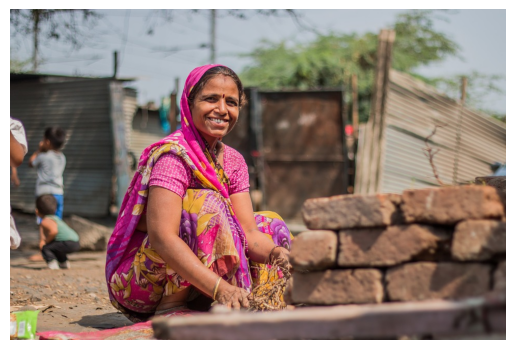

In [5]:
image = cv2.imread("woman1.jpg")  # make sure file exists
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")

In [6]:
output = image.copy()
faces = detect_faces(image)

print("Faces detected:", len(faces))

for (x1, y1, x2, y2) in faces:
    face = image[y1:y2, x1:x2]

    if face.size == 0:
        continue

    blob = cv2.dnn.blobFromImage(
        face, 1.0, (227,227),
        MODEL_MEAN_VALUES, swapRB=False
    )

    genderNet.setInput(blob)
    gender = GENDER_LIST[genderNet.forward()[0].argmax()]

    ageNet.setInput(blob)
    age = AGE_BUCKETS[ageNet.forward()[0].argmax()]

    label = f"{gender}, {age}"

    cv2.rectangle(output, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(output, label, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

Faces detected: 1


(np.float64(-0.5), np.float64(959.5), np.float64(639.5), np.float64(-0.5))

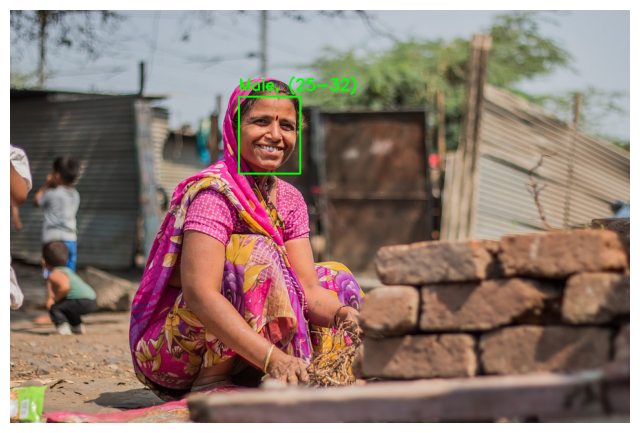

In [7]:
plt.figure(figsize=(8,8))
plt.imshow(output)
plt.axis("off")